# Field inference of a single (realistic) source with the Fast Multipole Method

This notebook calcuates the potential of a single source via the Fast Multipole Method in 2D (https://github.com/flatironinstitute/fmm2d) and serves as a benchmark for our novel method.

In [1]:
import numpy as np
import fmm2dpy as fmm
import matplotlib.pyplot as plt
import scienceplots  # noqa
import warnings

from hypermagnetics import plots
from hypermagnetics.sources import configure

warnings.filterwarnings('ignore')
plt.style.use(["science", "ieee"])

## I. Target definition and data generation

The dipole field at $\mathbf{r}$ from a collection of point-like sources with moments $\mathbf{m}_i$ and positions $\mathbf{r}_i$ is computed via the scalar potential as $${\mu_0}\mathbf{H}_{\odot}(\mathbf{r}) = -\nabla\sum_{i=1}^N \underbrace{\overbrace{\frac{1}{2\pi |\mathbf{r}-\mathbf{r_i}|}}^{\text{Surface of 2D ball}}\overbrace{\frac{\mathbf{m}_i\cdot(\mathbf{r}-\mathbf{r_i})}{|\mathbf{r}-\mathbf{r_i}|}}^{\text{dipole term}}}_{\text{scalar potential }\psi_i}.$$

We generate random samples to serve as the training data, precomputing the target potential values. First, we describe the collection of sources.

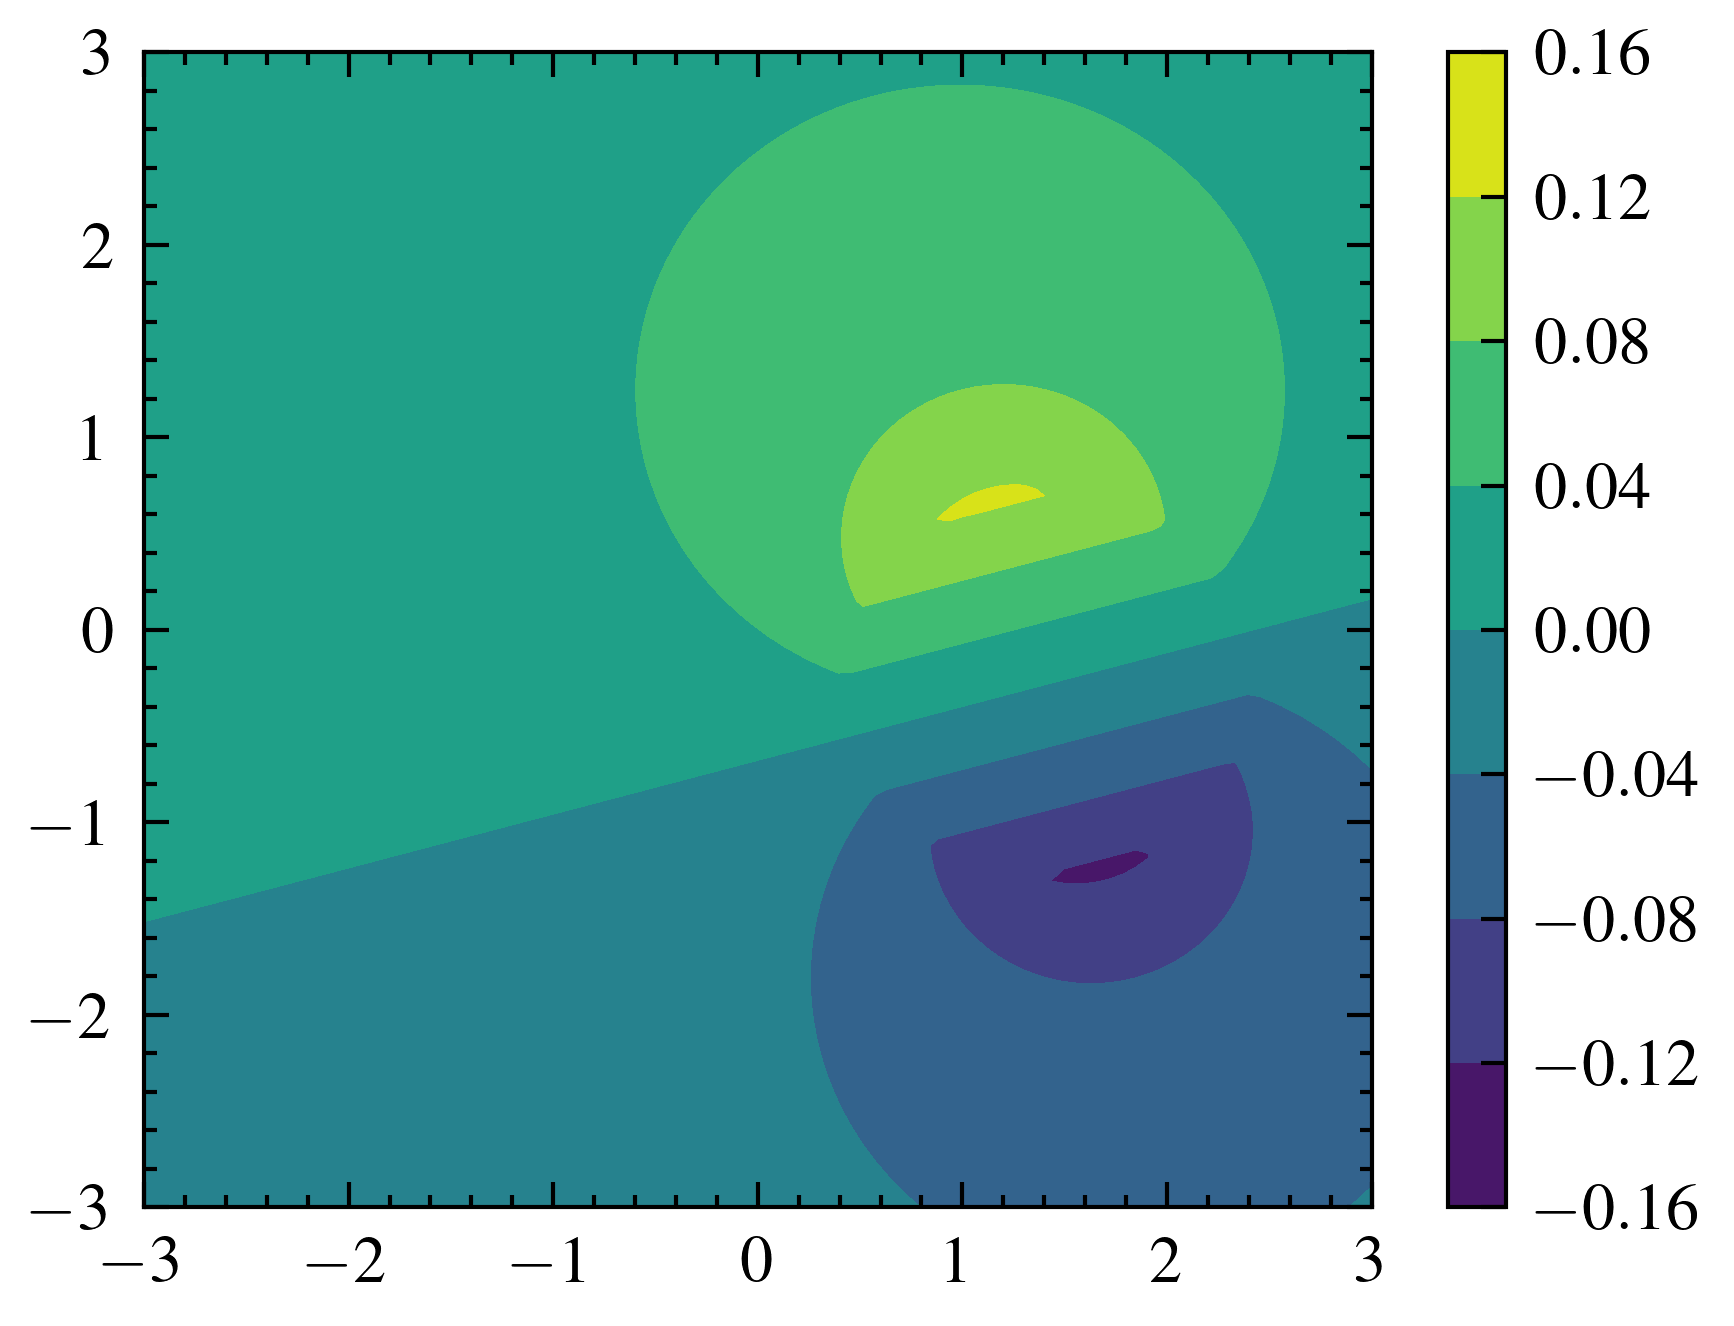

In [2]:
source_config = {
    "n_samples": 1,
    "lim": 3,
    "res": 100,
}
train = configure(**source_config, n_sources=1, seed=11)
val = configure(**source_config, n_sources=4)
# plots(train, None)
x_grid = np.array(train['grid'][:, 0].reshape((source_config["res"], source_config["res"])))
y_grid = np.array(train['grid'][:, 1].reshape((source_config["res"], source_config["res"])))
target_potential = train["potential_grid"][0 : 1].reshape((len(train["sources"][0 : 1]), source_config["res"], source_config["res"]))
plt.contourf(x_grid, y_grid, np.clip(target_potential[0], -1, 1))
plt.colorbar()

In [ ]:
sim = train.copy()

mr = sim["sources"][0:1]
m, r0, size = np.split(mr, 3, axis=-1)
# Division by circumference of the source
m_pure = m / (2 * np.pi * size[0, 0, 0])
# Adapt to syntax of fmm2dpy [1,1,2] to [2,1]
out = fmm.rfmm2d(
    eps=10 ** (-5),
    sources=r0[0].swapaxes(0, 1),
    charges=None,
    dipstr=np.array([np.linalg.norm(m_pure)]),
    dipvec=-m_pure[0].swapaxes(0, 1) / np.linalg.norm(m_pure),
    targets=train["grid"].swapaxes(0, 1),
    nd=source_config["n_samples"],
    pg=0,
    pgt=1,
)
sim['potential_grid'] = np.array([out.pottarg])
distances = np.linalg.norm(train["grid"] - r0[0], axis=1)
circle_indices = np.where(distances <= size[0, 0, 0])[0]
m_dot_r = np.array([np.dot(m[0][0], train["grid"][idx] - r0[0][0]) for idx in circle_indices])
sim['potential_grid'][0, circle_indices] = (m_dot_r / size[0, 0, 0] / (2 * np.pi * size[0, 0, 0]))
# sim['field_grid'] = (-1) * np.array([out.gradtarg.swapaxes(0, 1)])

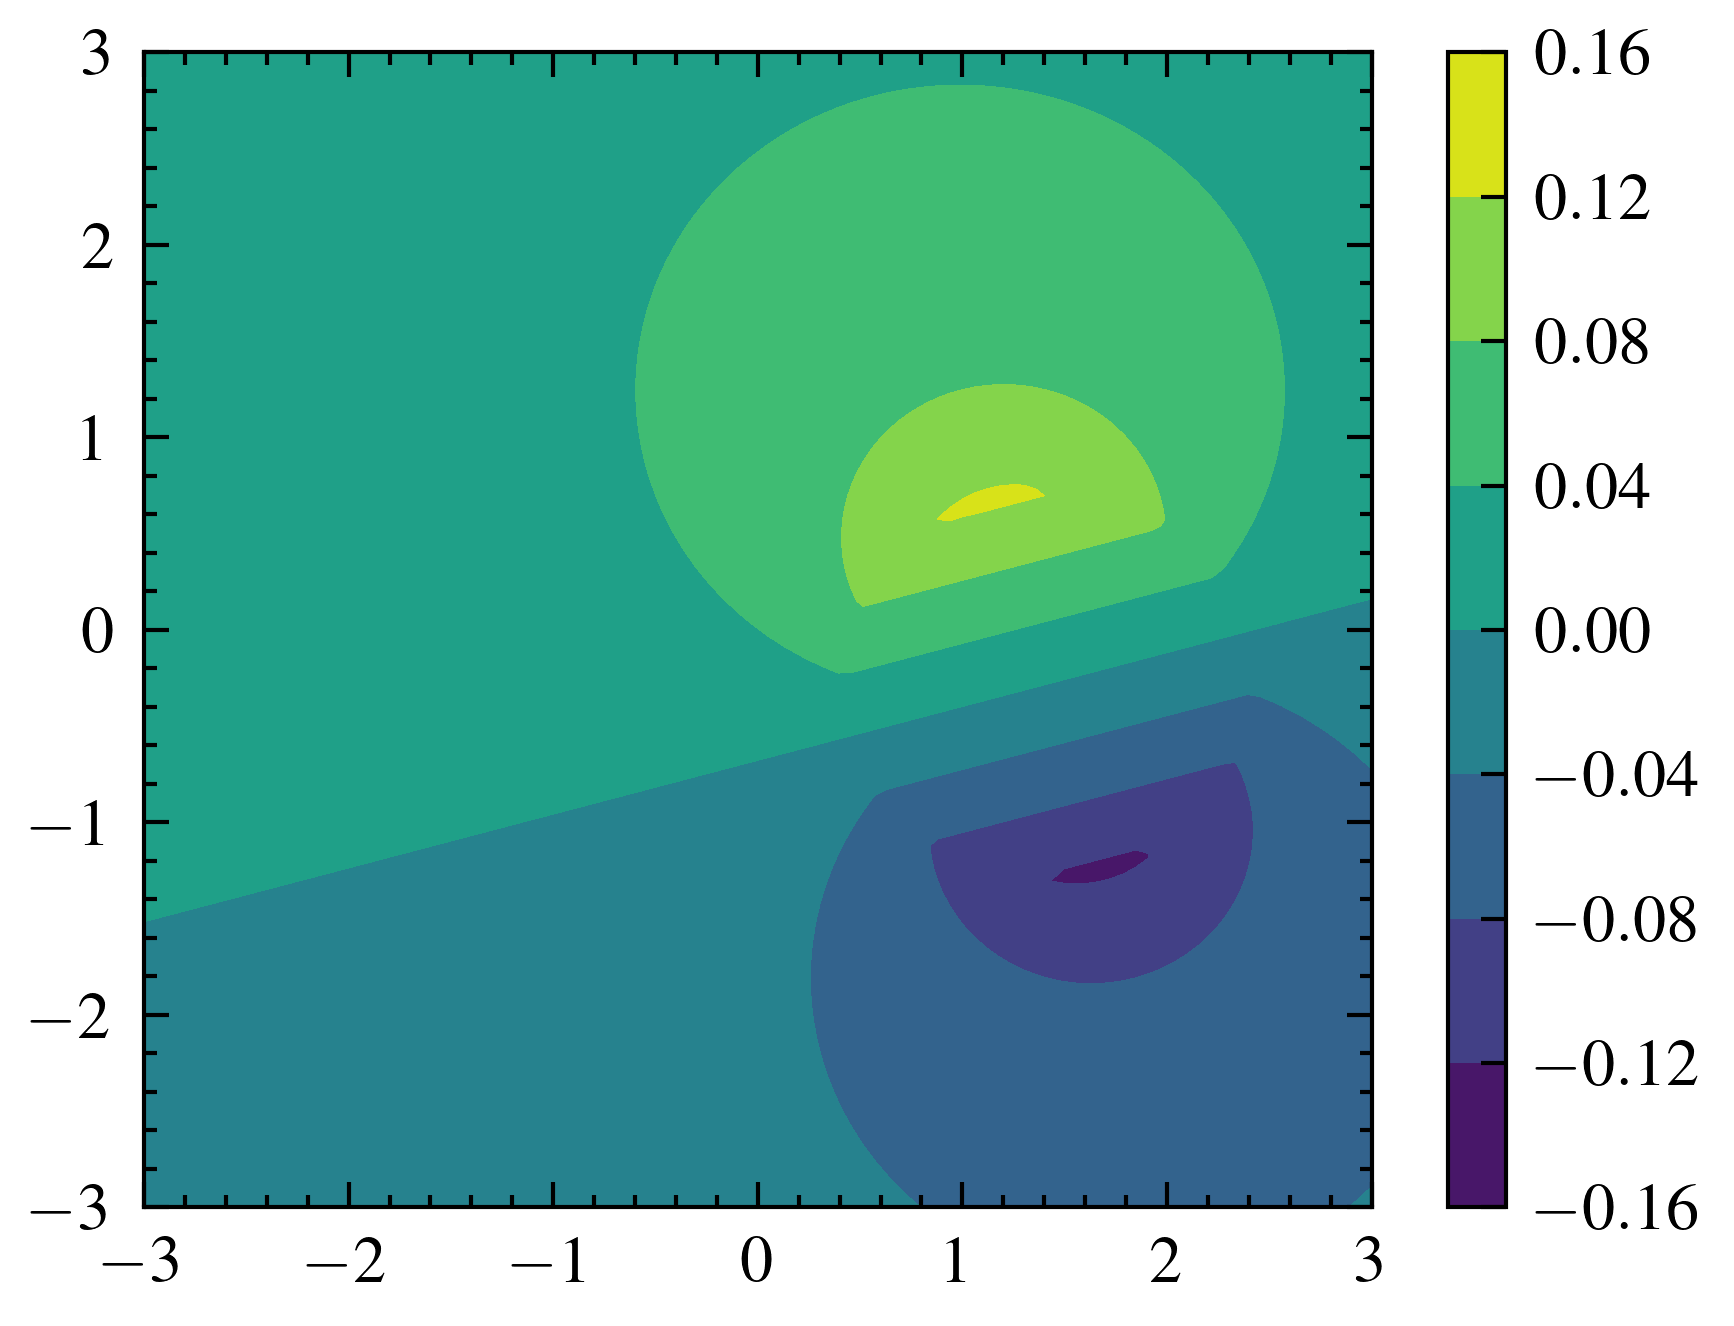

In [36]:
sim_potential = sim["potential_grid"][0 : 1].reshape((len(train["sources"][0 : 1]), source_config["res"], source_config["res"]))
plt.contourf(x_grid, y_grid, np.clip(sim_potential[0], -0.16, 0.16))
# plt.contourf(x_grid, y_grid, np.clip(sim_potential[0] - target_potential[0], -0.16, 0.16))
plt.colorbar()

A realistic (non-pointlike) source will have, in two dimensions, the form $\mathbf{H}(\mathbf{r}) = - \mathbb{N}(\mathbf{r})\mathbf{M}$ inside the source, and by Gauss' Law $\mathbf{H} \sim \mathbf{H}_\odot$ outside it. The distinguishing feature of the dipole term is the $\sim 1/r$ dependence; higher multipole terms ($1/r^2$, $1/r^3$) might also be included, but the dipole term will quickly dominate at larger $r$.

In our simulation, we assume to have a ball of uniform magnetization. To achieve a solution via the FMM framework, we can try to imitate that by multiple pointlike dipoles inside the realistic source.

In [24]:
sim_ball = train.copy()

idx = 0
mr = sim["sources"][idx : idx + 1]
m, r0, size = np.split(mr, 3, axis=-1)

ns = 2000000  # number of source poitns
radius = 1  # radius of circle

# generate n random angles
angles = np.random.uniform(0, 2*np.pi, ns)

# convert angles to Cartesian coordinates
x = radius * np.cos(angles) + r0[0][0][0]
y = radius * np.sin(angles) + r0[0][0][1]

points = np.column_stack((x, y)).swapaxes(0, 1)

dipstr = np.sqrt(m[0][0][0]**2 + m[0][0][1]**2)
dipvec = m[0].swapaxes(0, 1) / dipstr

out = fmm.lfmm2d(
    eps=10 ** (-5),
    sources=points,
    dipstr=np.repeat(np.array([dipstr]), repeats=ns, axis=-1),
    dipvec=np.repeat(dipvec, repeats=ns, axis=-1),
    targets=train["grid"].swapaxes(0, 1),
    nd=source_config["n_samples"],
    pg=0,
    pgt=2,
)
sim_ball['potential_grid'] = np.array([out.pottarg])
sim_ball['field_grid'] = np.real(np.array([out.gradtarg.swapaxes(0, 1)]))

 Reallocating
 Reallocating
 Reallocating
 Reallocating
 Reallocating
 Reallocating
